## Overview

This notebook implements a score based anomaly detection pipeline on the MNIST dataset using denoising score matching. A neural network is trained to approximate the score function, defined as the gradient of the log density of noise perturbed data, using only digit 0 as the normal class. At test time, each image is evaluated at multiple noise strenghts $\sigma$, and the magnitude of the learned score field is used as a measure of how strongly the image must be corrected to resemble the learned normal data distribution. The score magnitudes for each $\sigma$ are aggregated into a single anomaly score per image by taking the average $A$. The method is evaluated on the full MNIST test set by treating digit 0 as normal and digits 1 through 9 as anomalies, and anomaly decisions are made by thresholding the score to achieve a fixed false positive rate on normal data. This notebook provides a complete, end to end demonstration of score based anomaly detection, from training through evaluation and thresholded decision making.

### Step 1: Load MNIST Dataset
MNIST images are grayscale, so there is only one channel that controls how light or dark a pixel is, unlike RGB images that have three channels <R, G, B>.

Images are 28 x 28 pixels, e.g. the sample at index 0 of train_dataset is a grayscale image represented as a tensor of shape (1, 28, 28) with the label 5.

The shape is (C, H, W), where C is the number of channels, H is height in pixels, and W is width in pixels.

In [1]:
from torchvision import datasets, transforms

# Define a transform to convert images to tensors
#   Converts the image into a numerical array
#   Changes the layout into PyTorch’s standard format (channels, height, width)
transform = transforms.ToTensor()

# Download and load training data
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download and load test data
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Access a single example
# train_dataset[0] returns a tuple (image dimensions, label)
image, label = train_dataset[0]
print(image.shape, label)

torch.Size([1, 28, 28]) 5


#### Show a sample image from MNIST dataset

Matplotlib expects a 2D array for grayscale images. The tensor is 3D because PyTorch explicitly stores channels. We need to squeze the tensor to get rid of the channel, e.g. (1, 28, 28) becomes (28, 28) after we squeeze.

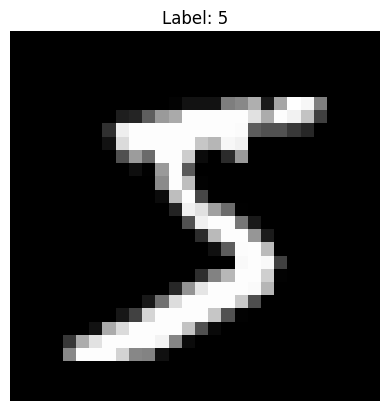

In [2]:
import matplotlib.pyplot as plt

# Get the first sample
image, label = train_dataset[0]

# Remove the channel dimension: (1, 28, 28) → (28, 28)
image_2d = image.squeeze(0)

# Plot the image
plt.imshow(image_2d, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

### Step 2: Set aside training dataset

We will only use images labeled 0 for our training. Recall that any digit that is not 0 is treated as an anomaly.

We will train the neural network on 0s only, but the images will be corrupted with some noise.

In [3]:
import torch
from torch.utils.data import DataLoader, Subset

# 1) Get labels from the torchvision MNIST dataset
# For MNIST, labels are stored in train_dataset.targets (a torch tensor)
targets = train_dataset.targets  # shape: (60000,)

# 2) Find indices where label == 0
zero_indices = (targets == 0).nonzero(as_tuple=True)[0]

# 3) Create a filtered dataset containing only zeros
train_dataset_0 = Subset(train_dataset, zero_indices)

print("Original train size:", len(train_dataset))
print("Filtered train size (digit 0 only):", len(train_dataset_0))

# 4) Create a DataLoader for training
train_loader_0 = DataLoader(
    train_dataset_0,
    batch_size=128, # Each batch is a tensor containing 128 grayscale images, each with 28 × 28 pixels.
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)


Original train size: 60000
Filtered train size (digit 0 only): 5923


##### Sanity check:
- Expect the batch size to be 128 grayscale images each with 28 x 28 pixels.
- The unique labels should only contain 0.

In [4]:
# Grab one batch and check labels
images, labels = next(iter(train_loader_0))
print("Batch images shape:", images.shape)  # expected: [128, 1, 28, 28]
print("Unique labels in batch:", torch.unique(labels))  # expected: tensor([0])


Batch images shape: torch.Size([128, 1, 28, 28])
Unique labels in batch: tensor([0])


### Step 3: Define a range of noise strengths (sigma values)

We will corrupt the original image, $x$, with Gaussian noise, $\epsilon$, sampled from $N(0,I)$. The intensity of the noise added is controlled by $\sigma$. The corrupted image is denoted as $\tilde{x}$.

$\tilde{x} = x + \sigma\epsilon$

We can interpret this component-wise on the pixel level of the image:

$\tilde{x}_{ij}=x_{ij}+\sigma\epsilon_{ij}$ where
- $x_{ij}$ is a pixel value
- $\epsilon_{ij}$ is standard normal noise
- $\sigma$ controls how strong the noise added is

$\sigma=0.01$ barely changes the image, $\sigma=0.1$ blurs the image. The stronger the value of $\sigma$ the more blurry the image gets.


Note that we are deciding on how much noise to add to each training image. We do not always add the same amount of noise. Instead, every time we take an image, we randomly choose a noise strength $\sigma$.

This step answers the question: How should we randomly choose $\sigma$?


In [ ]:
# [Logistics] : check whether running cpu or gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


We will sample $\sigma$ from a log uniform distribution defined by $\sigma_{min}$ and $\sigma_{max}$. First, we have to set $\sigma_{min}$ and $\sigma_{max}$ to a predefined value.

In [6]:
sigma_min = 0.01
sigma_max = 0.3

##### Why sample $\sigma$ from a log-uniform distribution?

We sample $\sigma$ from a log-uniform distribution because we want small $\sigma$ values to be more likely sampled. We want to sample small $\sigma$ values because training the model on images that has been slightly corrupted, i.e. small $\sigma$ values, allows the model to recognize what the digit "0" looks like. A log-uniform distribution allows this kind of sampling.

We want the model to learn how to fix tiny perturbations to an image. Large $\sigma$ values mostly destroys the image, so training on too many large $\sigma$ samples teaches the model almost nothing useful (a very blurred image could be anything). Furthermore, by sampling $\sigma$, we teach the model what a "0" looks like under many noise strengths (in the range of $\sigma_{min}$ and $\sigma_{max}$). Note that we are not ignoring large values of $\sigma$; they still get sampled (just less often).

##### 'sample_sigma' helper function

The code cell below defines a helper function `sample_sigma(batch_size, device)` which samples one $\sigma$ per image from a log-uniform distribution between $\sigma_{min}$ and $\sigma_{max}$.

This helper function returns a tensor of size $\textrm{batch\_size}$ with values of $\sigma$ bounded by $\sigma_{min}$ and $\sigma_{max}$.

The returned tensor will be added to the original images to corrupt them with noise.

In [7]:
def sample_sigma(batch_size, device):
    """
    Samples one sigma per image from a log-uniform distribution.
    Returns a tensor of shape (batch_size,)
    """
    log_sigma_min = torch.log(torch.tensor(sigma_min, device=device))
    log_sigma_max = torch.log(torch.tensor(sigma_max, device=device))

    # Uniform sampling in log-space
    log_sigma = torch.rand(batch_size, device=device) * (log_sigma_max - log_sigma_min) + log_sigma_min

    # Convert back to sigma
    sigma = torch.exp(log_sigma)
    return sigma

##### Sanity check
- Sigma shape must be equal to batch size
- Sigma min must be $\geq$ $\sigma_{min}$
- Sigma max must be $\leq$ $\sigma_{max}$

The code cell below samples a batch of digit "0" images, draws one sigma per image, and prints the sigma tensor shape and its min and max values. Confirm that sigmas are sampled correctly and fall within the intended range.


In [39]:
images, _ = next(iter(train_loader_0))
images = images.to(device)

batch_size = images.shape[0]

sigma = sample_sigma(batch_size, device)

print("Sigma shape:", sigma.shape)
print("Sigma min:", sigma.min().item())
print("Sigma max:", sigma.max().item())

Sigma shape: torch.Size([128])
Sigma min: 0.010083376429975033
Sigma max: 0.269080251455307


### Step 4: Noise corruption

##### Why do we corrupt the images?

The score we want is $\nabla_x\mathrm{log}\hspace{0.05cm}p_{data}(x)$, but we do not know the score of the true data distribution, $p_{data}$. We only have samples.

To make the problem solvable, we add Gaussian noise. Given:

$$
\tilde{x} = x + \sigma\epsilon
$$

The distribution of $\tilde{x}$ given $x$ and $\sigma$ is known, exactly:

$$
p(\tilde{x}|x,\sigma) = N(x,\sigma^2I)
$$

This is a standard multivariate normal. Now, we can compute its score:

$$
\nabla_{\tilde{x}}\mathrm{log}\hspace{0.05cm}p(\tilde{x}|x,\sigma)=\frac{x-\tilde{x}}{\sigma^2}
$$

Key observation:

The vector $\frac{x-\tilde{x}}{\sigma^2}$ is telling us the direction to move the noisy image back toward it came from. 

This will be what the neural network is trained to predict. The neural network will consist of two inputs (image and $\sigma$)

Now, we generate $\epsilon \sim N(0, I)$ with the same shape as the image batch. This noise is used to construct noisy inputs for score matching.


In [41]:
# images: (B, 1, 28, 28)
epsilon = torch.randn_like(images)  # same shape as images, values ~ N(0,1)
print(images.shape)
print(epsilon.shape)
print(epsilon)

torch.Size([128, 1, 28, 28])
torch.Size([128, 1, 28, 28])
tensor([[[[-7.9688e-01,  2.5801e+00, -1.0073e+00,  ..., -1.1302e+00,
            7.9950e-01, -6.6379e-01],
          [-5.8089e-02,  1.0037e+00,  1.1730e+00,  ..., -4.0929e-01,
           -1.4925e-01, -5.0938e-01],
          [ 2.4280e-01, -1.0928e+00, -8.7368e-01,  ...,  1.7315e-01,
           -1.5223e+00,  1.7653e-01],
          ...,
          [-8.6685e-01, -9.8398e-01,  1.1546e+00,  ..., -5.5024e-01,
            7.2037e-01,  5.6454e-01],
          [-5.2952e-01,  1.0457e+00, -7.5034e-01,  ..., -3.0347e-01,
           -1.5272e-01,  8.0412e-01],
          [ 1.9515e+00, -1.5111e-02,  2.2912e-01,  ..., -4.8460e-01,
            9.9069e-01, -1.2751e+00]]],


        [[[ 2.4243e-01,  9.8548e-02, -2.9159e-01,  ..., -6.9354e-01,
           -1.6657e-01, -3.1466e-01],
          [ 2.8175e+00, -1.2071e-01,  2.4757e-01,  ..., -1.0636e+00,
            3.7128e-01, -2.6247e-02],
          [ 1.5409e-01,  1.6468e+00, -2.0178e-01,  ..., -4.4412e-01

Reshape `sigma` from `[B]` to `[B, 1, 1, 1]` so it can be multiplied with `epsilon` and added to the image tensor using broadcasting.


In [31]:
sigma_broadcast = sigma.view(-1, 1, 1, 1)  # shape: (B, 1, 1, 1)
print(sigma_broadcast.shape)

torch.Size([128, 1, 1, 1])


Corrupt the original image $x$ following the equation $\tilde{x} = x + \sigma\epsilon$

This constructs noisy images using `x_tilde = images + sigma * epsilon`. This implements the forward corruption process used in denoising score matching.

In [11]:
x_tilde = images + sigma_broadcast * epsilon

##### Sanity check

Prints shapes of `images`, `sigma`, `sigma_broadcast`, `epsilon`, and `x_tilde` to confirm the corruption pipeline is dimensionally consistent.

In [12]:
print("images:", images.shape)
print("sigma:", sigma.shape)
print("sigma_broadcast:", sigma_broadcast.shape)
print("epsilon:", epsilon.shape)
print("x_tilde:", x_tilde.shape)


images: torch.Size([128, 1, 28, 28])
sigma: torch.Size([128])
sigma_broadcast: torch.Size([128, 1, 1, 1])
epsilon: torch.Size([128, 1, 28, 28])
x_tilde: torch.Size([128, 1, 28, 28])


Visually observe the corrupted images. See how the value of $\sigma$ affects the clarity of the image.
- Larger $\sigma$ reduces the clarity of the image (i.e. more noisy)

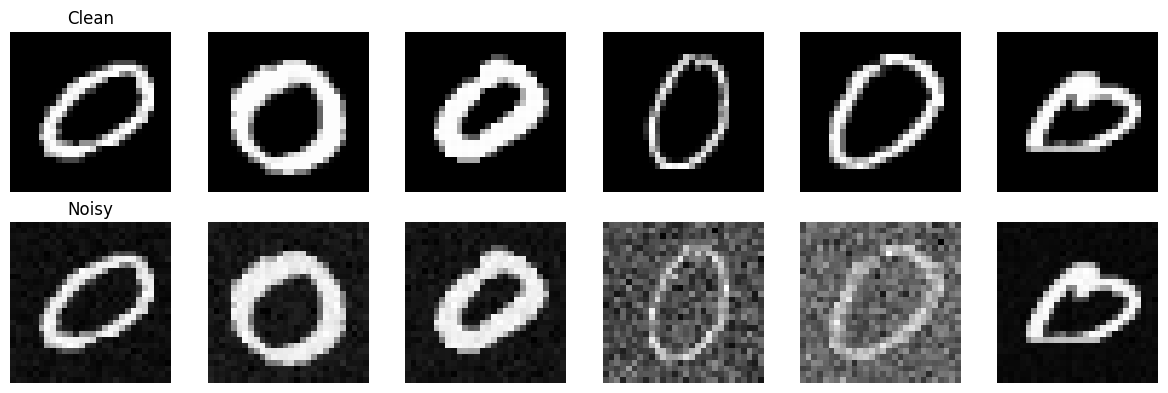

In [13]:
# Take a small subset for visualization
num_images = 6

images_vis = images[:num_images].detach().cpu()
x_tilde_vis = x_tilde[:num_images].detach().cpu()

fig, axes = plt.subplots(2, num_images, figsize=(12, 4))

for i in range(num_images):
    # Clean images (top row)
    axes[0, i].imshow(images_vis[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Clean")

    # Noisy images (bottom row)
    axes[1, i].imshow(x_tilde_vis[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Noisy")

plt.tight_layout()
plt.show()

### Step 5: Defining and training the neural network to calculate score

Define the score network which is conditioned on $\sigma$. The network has two inputs:
- the image
- $\sigma$ the noise strength

The output of the network is the gradient of the score function
- score

##### Why the network needs $\sigma$ as input?

The same noisy image, $\tilde_{x}$, can be produced by different $\sigma$ values.

Recall that the network is trained to predict $\frac{x-\tilde{x}}{\sigma^2}$. The correction needed for a corrupted image depends strongly on $\sigma$. Small $\sigma$ means tiny corrections, whereas large $\sigma$ means large corrections. If the network does not know $\sigma$, it cannot scale its output correctly.



Implements a convolutional neural network that predicts a score field with the same shape as the input image. The model conditions on noise level by injecting `log(sigma)` as an additional channel, enabling a single network to represent scores across multiple noise scales.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ScoreNet(nn.Module):
    """
    Input:
      x_tilde: [B, 1, 28, 28]
      sigma:   [B] (as in your Step 3)
    Output:
      score:   [B, 1, 28, 28]
    """
    def __init__(self, base_channels=64):
        super().__init__()
        c = base_channels

        # 2 input channels: image + log_sigma channel
        self.conv1 = nn.Conv2d(2, c, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(c, c, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(c, c, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(c, 1, kernel_size=3, padding=1)

        self.gn1 = nn.GroupNorm(8, c)
        self.gn2 = nn.GroupNorm(8, c)
        self.gn3 = nn.GroupNorm(8, c)

    def forward(self, x_tilde, sigma):
        # sigma is [B], convert to [B,1,1,1]
        sigma_broadcast = sigma.view(-1, 1, 1, 1)
        log_sigma = torch.log(sigma_broadcast + 1e-12)

        # expand to an image-sized channel
        sigma_channel = log_sigma.expand(-1, 1, x_tilde.shape[2], x_tilde.shape[3])
        h = torch.cat([x_tilde, sigma_channel], dim=1)

        h = F.silu(self.gn1(self.conv1(h)))
        h = F.silu(self.gn2(self.conv2(h)))
        h = F.silu(self.gn3(self.conv3(h)))
        out = self.conv4(h)
        return out


For Gaussian noise corruption $\tilde{x} = x + \sigma\epsilon$, We train the network to predict this score:

$\nabla_{\tilde{x}}\mathrm{log}\hspace{0.05cm}p(\tilde{x}|x)=\frac{x-\tilde{x}}{\sigma^2}$

which is the Gaussian noise added to the image with strength noise $\sigma$ 


Computes mean squared error between predicted and target score fields, with sigma dependent weighting to balance contributions across noise scales.


In [15]:
def dsm_loss(model, images, sigma, x_tilde):
    """
    images:  [B,1,28,28]
    sigma:   [B]
    x_tilde: [B,1,28,28]
    """
    sigma_broadcast = sigma.view(-1, 1, 1, 1)

    target = (images - x_tilde) / (sigma_broadcast ** 2)  # [B,1,28,28]
    pred = model(x_tilde, sigma)                          # [B,1,28,28]

    # Optional but recommended weighting to balance scales
    weight = sigma_broadcast ** 2
    loss = (weight * (pred - target) ** 2).mean()
    return loss


Training loop

Initializes the model and optimizer, and defines a training loop. 

Each iteration:
- samples sigma, 
- corrupts images, 
- computes DSM (denoising score matching) loss, and
- updates model parameters.


In [42]:
from torch.optim import AdamW

model = ScoreNet(base_channels=64).to(device)
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def train_one_epoch(model, train_loader, optimizer, epoch, log_every=100):
    model.train()
    running = 0.0

    for step, (images, _) in enumerate(train_loader):
        images = images.to(device)  # [B,1,28,28]
        batch_size = images.shape[0]

        # sample sigma (shape [B])
        sigma = sample_sigma(batch_size, device)

        # corrupt images
        epsilon = torch.randn_like(images)
        sigma_broadcast = sigma.view(-1, 1, 1, 1)
        x_tilde = images + sigma_broadcast * epsilon

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            loss = dsm_loss(model, images, sigma, x_tilde)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        if (step + 1) % log_every == 0:
            print(f"epoch {epoch} step {step+1}/{len(train_loader)} loss={running/log_every:.6f}")
            running = 0.0

num_epochs = 5
for epoch in range(1, num_epochs + 1):
    train_one_epoch(model, train_loader_0, optimizer, epoch, log_every=100)

/tmp/ipykernel_1235/3879933167.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_1235/3879933167.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


##### Sanity check: shape and finiteness check

Runs a forward pass on a small batch of corrupted images and verifies that the predicted score has the correct shape and finite values. Confirms that the conditioning interface `model(x_tilde, sigma)` is working.

In [17]:
model.eval()
images, _ = next(iter(train_loader_0))
images = images.to(device)[:8]
sigma = sample_sigma(images.shape[0], device)
epsilon = torch.randn_like(images)
x_tilde = images + sigma.view(-1,1,1,1) * epsilon

with torch.no_grad():
    pred = model(x_tilde, sigma)

print("images:", images.shape)
print("sigma:", sigma.shape)
print("x_tilde:", x_tilde.shape)
print("pred:", pred.shape)
print("pred finite:", torch.isfinite(pred).all().item())


images: torch.Size([8, 1, 28, 28])
sigma: torch.Size([8])
x_tilde: torch.Size([8, 1, 28, 28])
pred: torch.Size([8, 1, 28, 28])
pred finite: True


##### Sanity check: Loss value check

Computes DSM loss on a single batch without updating parameters. Confirms that the loss is finite and within a reasonable numerical range before relying on it for training or evaluation.

In [18]:
model.eval()
with torch.no_grad():
    loss_val = dsm_loss(model, images, sigma, x_tilde).item()
print("single-batch loss:", loss_val)

single-batch loss: 0.6159144043922424


The loss should generally decrease over k steps

In [ ]:
model.train()

# Fix one batch
images, _ = next(iter(train_loader_0))
images = images.to(device)

# Fix sigma and epsilon so the task stays identical across steps
sigma = sample_sigma(images.shape[0], device)
epsilon = torch.randn_like(images)
x_tilde = images + sigma.view(-1,1,1,1) * epsilon

for k in range(50): # k numbre of steps
    optimizer.zero_grad(set_to_none=True)
    loss = dsm_loss(model, images, sigma, x_tilde)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    print(f"step {k+1}: loss={loss.item():.6f}")


step 1: loss=0.652863
step 2: loss=0.652215
step 3: loss=0.651176
step 4: loss=0.650618
step 5: loss=0.650802
step 6: loss=0.649857
step 7: loss=0.650616
step 8: loss=0.650002
step 9: loss=0.649143
step 10: loss=0.648778
step 11: loss=0.648557
step 12: loss=0.647862
step 13: loss=0.648217
step 14: loss=0.647492
step 15: loss=0.647556
step 16: loss=0.647142
step 17: loss=0.646331
step 18: loss=0.645993
step 19: loss=0.645768
step 20: loss=0.645224
step 21: loss=0.645271
step 22: loss=0.644666
step 23: loss=0.644909
step 24: loss=0.644508
step 25: loss=0.643473
step 26: loss=0.643160
step 27: loss=0.643113
step 28: loss=0.642503
step 29: loss=0.642571
step 30: loss=0.642028
step 31: loss=0.641552
step 32: loss=0.641366
step 33: loss=0.640315
step 34: loss=0.640109
step 35: loss=0.639922
step 36: loss=0.639476
step 37: loss=0.639433
step 38: loss=0.639038
step 39: loss=0.638222
step 40: loss=0.637841
step 41: loss=0.637534
step 42: loss=0.636732
step 43: loss=0.637085
step 44: loss=0.6363

### Step 6: Multiple noise evaluations per test image

Define a tensor for the sigma values. Here we have:

$\sigma_1 = 0.01$

$\sigma_2 = 0.03$

$\sigma_3 = 0.1$

$\sigma_4 = 0.3$

Defines `score_norms_multi_sigma` which computes per image, per sigma score norms

For each sigma, it 
- corrupts the image, 
- computes the score field, and 
- records the L2 norm per image. 

This produces a multi scale feature vector per test sample.


In [24]:
import torch

# Fixed noise levels for evaluation
sigmas = torch.tensor([0.01, 0.03, 0.1, 0.3], dtype=torch.float32)

@torch.no_grad()
def score_norms_multi_sigma(model, x, sigmas, device, mc_samples=1):
    """
    Step 6:
    For each image x in a batch and each sigma in sigmas:
      - sample epsilon
      - x_tilde = x + sigma * epsilon
      - g = s_theta(x_tilde, sigma)
      - n = ||g||_2  (over all pixels)

    Args:
      model: trained ScoreNet
      x: [B,1,28,28]
      sigmas: [K] tensor of noise levels (CPU or GPU)
      device: torch.device
      mc_samples: number of Monte Carlo noise draws per sigma (default 1)

    Returns:
      norms: [B,K] where norms[b,k] = average over mc_samples of L2 norm of score field
    """
    model.eval()
    x = x.to(device)
    sigmas = sigmas.to(device)

    B = x.shape[0]
    K = sigmas.shape[0]

    # Accumulate norms across MC samples
    norms_accum = torch.zeros(B, K, device=device)

    for m in range(mc_samples):
        for k in range(K):
            sigma_k = sigmas[k]
            sigma_vec = sigma_k.repeat(B)                     # [B]
            eps = torch.randn_like(x)                         # [B,1,28,28]
            x_tilde = x + sigma_k * eps                       # broadcast scalar sigma_k

            g = model(x_tilde, sigma_vec)                     # [B,1,28,28]

            # L2 norm over all pixels per image:
            # flatten to [B, 1*28*28] then compute sqrt(sum(g^2))
            n_k = torch.sqrt(torch.sum(g.view(B, -1) ** 2, dim=1) + 1e-12)  # [B]
            norms_accum[:, k] += n_k

    norms = norms_accum / mc_samples
    return norms


Load the test dataset from the full MNIST test dataset. This includes all digits 0 - 9.
This loader is used to compute anomaly scores for all test samples.

In [21]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


These are the labels inside the test dataset

In [23]:
images, labels = next(iter(test_loader))
print("labels:", labels[:128].tolist())

labels: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5]


#### Sanity check: test using MNIST test.
all_norms contains the norm $s_\theta(x_i+\sigma_k\epsilon,\sigma_k)$ for each $x_i$ data in test dataset. Recall that there are 10,000 data points in the test dataset and since we have 4 sigma values, the shape of all_norms will be torch.Size([10000, 4])

Iterates over all 10,000 MNIST test images, computes score norms at each sigma, and stores results in `all_norms` with shape `[N, K]` along with the corresponding digit labels in `all_labels`.

In [ ]:
all_norms = []
all_labels = []

mc_samples = 1  # keep 1 for now, increase later if you want stability

for images, labels in test_loader:
    norms_bk = score_norms_multi_sigma(model, images, sigmas, device, mc_samples=mc_samples)  # [B,K]
    all_norms.append(norms_bk.detach().cpu())
    all_labels.append(labels.detach().cpu())

all_norms = torch.cat(all_norms, dim=0)    # [N,K]
all_labels = torch.cat(all_labels, dim=0)  # [N]

print("all_norms:", all_norms.shape)
print("all_labels:", all_labels.shape)
print("sigmas:", sigmas.tolist())
print(all_norms[0]) # print what the first row of all_norms look like


all_norms: torch.Size([10000, 4])
all_labels: torch.Size([10000])
sigmas: [0.009999999776482582, 0.029999999329447746, 0.10000000149011612, 0.30000001192092896]
tensor([ 68.4471, 122.5533, 139.7723, 129.6779])


##### Sanity check

Evaluates a small set of test images, prints their true digit labels, and prints the per sigma norm matrix. This provides a quick qualitative check that norms vary across images and noise scales.

In [26]:
images, labels = next(iter(test_loader))
norms_bk = score_norms_multi_sigma(model, images[:8], sigmas, device, mc_samples=1)

print("labels:", labels[:8].tolist())
print("norms per image (rows) and sigma (cols):")
print(norms_bk.cpu())


labels: [7, 2, 1, 0, 4, 1, 4, 9]
norms per image (rows) and sigma (cols):
tensor([[ 66.9832, 119.6457, 139.2556, 129.1325],
        [ 75.8140, 119.1270, 137.3784, 122.8679],
        [ 60.2506, 121.8733, 139.5177, 133.1293],
        [ 75.5669, 115.6768, 135.1904, 112.7570],
        [ 76.8055, 119.4281, 139.6190, 127.4843],
        [ 61.3305, 123.7046, 139.3165, 128.1607],
        [ 74.9651, 122.8695, 139.7768, 126.4096],
        [ 76.4241, 120.2435, 137.2908, 127.4803]])


### Step 7: Aggregation into a single anomaly score

Average the score norms across noise levels:
$A(x) = \frac{1}{K} \sum_{n=k}^Kn_k$

This code cell computes the final anomaly score `A(x)` for each test image by averaging the per sigma norms across noise levels. Prints basic summary statistics to confirm the score tensor looks reasonable.

In [28]:
# all_norms: [N, K] where K=4
A = all_norms.mean(dim=1)  # [N]

print("A shape:", A.shape)
print("A min/mean/max:", A.min().item(), A.mean().item(), A.max().item())


A shape: torch.Size([10000])
A min/mean/max: 103.70367431640625 113.30746459960938 128.40597534179688


### Step 8: Score computation on test data

Splits test samples into digit 0 (normal) and non zero (anomaly) groups, then prints descriptive statistics for each group. This checks whether the score distribution shifts in the expected direction.

In [29]:
is_normal = (all_labels == 0)
A0 = A[is_normal]
Anon = A[~is_normal]

print("Count normal (0):", int(is_normal.sum()))
print("Count anomaly (!=0):", int((~is_normal).sum()))

print("Digit 0 A(x):    mean={:.4f} std={:.4f} median={:.4f}".format(
    A0.mean().item(), A0.std().item(), A0.median().item()
))
print("Non-0 A(x):      mean={:.4f} std={:.4f} median={:.4f}".format(
    Anon.mean().item(), Anon.std().item(), Anon.median().item()
))


Count normal (0): 980
Count anomaly (!=0): 9020
Digit 0 A(x):    mean=112.0949 std=2.5400 median=111.7628
Non-0 A(x):      mean=113.4392 std=2.6610 median=113.4603


In [32]:
# Step 8: Score computation on test data
# Assumes Step 6 produced: all_norms [10000, 4], all_labels [10000]
# Assumes Step 7 produced: A = all_norms.mean(dim=1) [10000]

# Ground truth binary labels:
# 0 = normal (digit 0)
# 1 = anomaly (digits 1-9)
y_true = (all_labels != 0).to(torch.int64)  # [10000]

print("A shape:", A.shape)
print("all_labels shape:", all_labels.shape)
print("y_true shape:", y_true.shape)

n_total = A.shape[0]
n_normal = int((y_true == 0).sum())
n_anom = int((y_true == 1).sum())

print("Total test samples:", n_total)
print("Normal (digit 0):", n_normal)
print("Anomaly (digits 1-9):", n_anom)


A shape: torch.Size([10000])
all_labels shape: torch.Size([10000])
y_true shape: torch.Size([10000])
Total test samples: 10000
Normal (digit 0): 980
Anomaly (digits 1-9): 9020


### Step 9: Thresholding

In [43]:
# Step 9: Thresholding

alpha = 0.01  # target false positive rate on digit 0 (e.g., 0.01, 0.05, 0.10)

A0 = A[all_labels == 0]
T = torch.quantile(A0, 1.0 - alpha).item()

print("Target FPR (alpha):", alpha)
print("Chosen threshold T:", T)
print("Digit-0 score quantile used:", 1.0 - alpha)


Target FPR (alpha): 0.01
Chosen threshold T: 119.64277648925781
Digit-0 score quantile used: 0.99


In [44]:
# Predict anomaly if score exceeds threshold
y_pred = (A > T).to(torch.int64)  # 1=anomaly, 0=normal

# Confusion matrix counts
TP = int(((y_true == 1) & (y_pred == 1)).sum())
TN = int(((y_true == 0) & (y_pred == 0)).sum())
FP = int(((y_true == 0) & (y_pred == 1)).sum())
FN = int(((y_true == 1) & (y_pred == 0)).sum())

tpr = TP / (TP + FN + 1e-12)      # recall
fpr = FP / (FP + TN + 1e-12)
precision = TP / (TP + FP + 1e-12)
recall = tpr
f1 = 2 * precision * recall / (precision + recall + 1e-12)
acc = (TP + TN) / (TP + TN + FP + FN + 1e-12)

print("Confusion matrix")
print("TP:", TP, "FP:", FP)
print("FN:", FN, "TN:", TN)

print("Metrics at threshold T")
print("Accuracy:   {:.4f}".format(acc))
print("TPR/Recall: {:.4f}".format(tpr))
print("FPR:        {:.4f}".format(fpr))
print("Precision:  {:.4f}".format(precision))
print("F1:         {:.4f}".format(f1))

# Confirm achieved FPR on digit 0 specifically
empirical_fpr0 = float((A0 > T).float().mean().item())
print("Empirical FPR on digit 0:", empirical_fpr0)


Confusion matrix
TP: 106 FP: 10
FN: 8914 TN: 970
Metrics at threshold T
Accuracy:   0.1076
TPR/Recall: 0.0118
FPR:        0.0102
Precision:  0.9138
F1:         0.0232
Empirical FPR on digit 0: 0.010204081423580647
